# S2 quality model: fixed neighbourhood

This notebook trains one time-conditioned XGBoost model for LNS neighbourhood size 4. MovingAI and POGEMA both use random instance-disjoint five-fold evaluation.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

from mapf_anytime.features import LACAM_FEATURES, STATIC_FEATURES
from mapf_anytime.metacognitive.learnable_fixed import LNS_PARAMETERS

TIMESTEPS = (1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 100.0)
TARGETS = tuple(f"target_sodlb_{second:g}s" for second in TIMESTEPS)
TIME_FEATURE = "lns_time_seconds"
BASE_FEATURES = (*STATIC_FEATURES, *LACAM_FEATURES)
NEIGHBOURHOOD_SIZE = 4
FOLDS = 5
SEED = 42
JOBS = -1
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

def load_dataset(path):
    data = pd.read_csv(path)
    if "lacam_seed" not in data:
        data["lacam_seed"] = 0
    data = data[data.lns_neighborhood_size.eq(NEIGHBOURHOOD_SIZE)].copy()
    parsed = data.lns_best_sod_by_second.map(json.loads)
    valid = parsed.map(len).gt(max(TIMESTEPS))
    data, parsed = data.loc[valid].copy(), parsed.loc[valid]
    curves = np.minimum.accumulate(np.vstack(parsed).astype(float), axis=1)
    denominator = data.lower_bound_soc.replace(0, np.nan)
    data["target_cap"] = data.lacam_initial_sod / denominator
    for second, target in zip(TIMESTEPS, TARGETS):
        incumbent = curves[:, int(second)]
        data[target] = np.minimum(
            ((data.lacam_initial_sod - incumbent) / denominator).clip(lower=0),
            data.target_cap,
        )
    required = ["instance_id", "map_name", "lacam_seed", "target_cap", *BASE_FEATURES, *TARGETS]
    data[required] = data[required].replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=required).reset_index(drop=True)
    if data.duplicated(["instance_id", "lacam_seed"]).any():
        raise ValueError("Expected one n=4 row per instance and LaCAM seed")
    return data

movingai = load_dataset(ROOT / "datasets/movingai_final.csv")
pogema = load_dataset(ROOT / "datasets/pogema_final.csv")
display(pd.DataFrame({
    "seed runs": [len(movingai), len(pogema)],
    "base instances": [movingai.instance_id.nunique(), pogema.instance_id.nunique()],
    "maps": [movingai.map_name.nunique(), pogema.map_name.nunique()],
}, index=["MovingAI", "POGEMA"]))

,seed runs,base instances,maps
MovingAI,17488,4432,33
POGEMA,18377,4677,4677


## Full-dataset improvement distributions

SOD/LB improvement after 100 seconds of LNS with neighbourhood size 4.

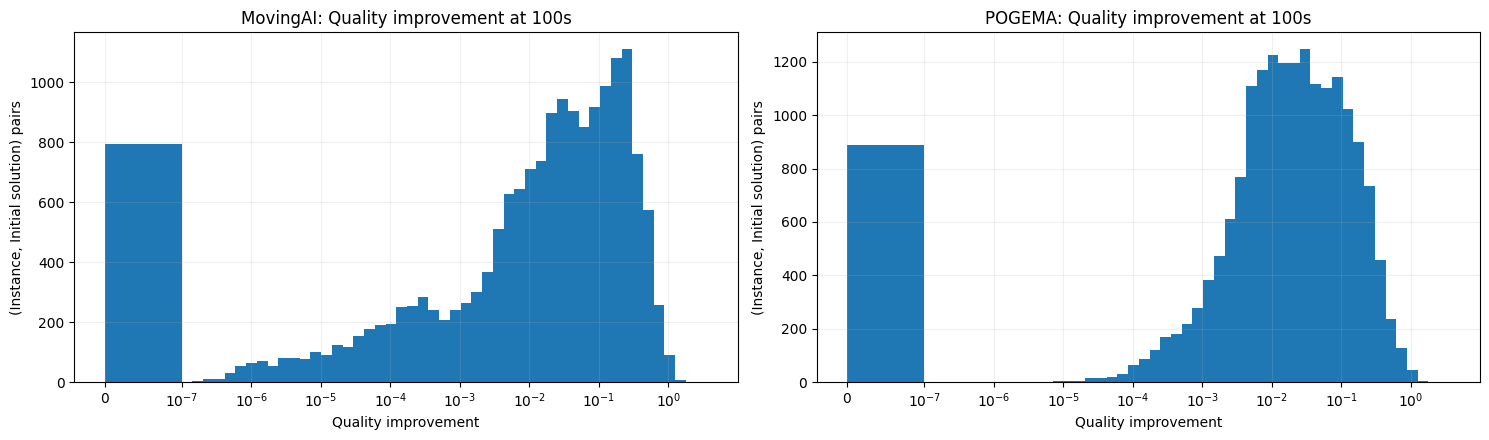

In [2]:
target_100s = "target_sodlb_100s"
plot_max = max(movingai[target_100s].max(), pogema[target_100s].max())
bins = np.concatenate(([0.0], np.geomspace(1e-7, plot_max, 50)))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=False)
for axis, (name, data) in zip(
    axes, (("MovingAI", movingai), ("POGEMA", pogema))
):
    axis.hist(data[target_100s], bins=bins)
    axis.set_xscale("symlog", linthresh=1e-7)
    axis.set(
        title=f"{name}: Quality improvement at 100s",
        xlabel="Quality improvement",
        ylabel="(Instance, Initial solution) pairs",
    )
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [3]:
def random_group_splits(data):
    instances = data[["instance_id"]].drop_duplicates().reset_index(drop=True)
    for train, test in KFold(FOLDS, shuffle=True, random_state=SEED).split(instances):
        train_ids = set(instances.iloc[train].instance_id)
        test_ids = set(instances.iloc[test].instance_id)
        yield (
            np.flatnonzero(data.instance_id.isin(train_ids)),
            np.flatnonzero(data.instance_id.isin(test_ids)),
        )

def design(frame, features=BASE_FEATURES):
    rows = frame.loc[
        frame.index.repeat(len(TIMESTEPS)), list(features)
    ].reset_index(drop=True)
    rows[TIME_FEATURE] = np.tile(TIMESTEPS, len(frame))
    return rows[[*features, TIME_FEATURE]]

def fit_model(training, seed, features=BASE_FEATURES):
    estimator = XGBRegressor(
        objective="reg:squarederror", tree_method="hist", n_jobs=JOBS,
        random_state=seed, **LNS_PARAMETERS,
    )
    target = training[list(TARGETS)].to_numpy().reshape(-1)
    estimator.fit(design(training, features), np.log1p(target))
    return estimator

def predict_model(estimator, evaluation, features=BASE_FEATURES):
    prediction = np.expm1(estimator.predict(design(evaluation, features)))
    prediction = prediction.reshape(len(evaluation), len(TIMESTEPS))
    return np.clip(prediction, 0, evaluation.target_cap.to_numpy()[:, None])

def evaluate(data, splits, features=BASE_FEATURES):
    prediction = np.full((len(data), len(TIMESTEPS)), np.nan)
    models = []
    for fold, (train, test) in enumerate(splits, start=1):
        assert set(data.iloc[train].instance_id).isdisjoint(data.iloc[test].instance_id)
        estimator = fit_model(data.iloc[train], SEED + fold, features)
        prediction[test] = predict_model(estimator, data.iloc[test], features)
        models.append(estimator)
    if not np.isfinite(prediction).all():
        raise RuntimeError("Some rows did not receive OOF predictions")
    return prediction, models

def metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mean = np.asarray(actual).mean()
    return {
        "R²": r2_score(actual, predicted),
        "MAE": mae,
        "MAE / mean": mae / mean if mean else np.nan,
    }

def baseline(data, splits):
    prediction = np.full((len(data), len(TIMESTEPS)), np.nan)
    for train, test in splits:
        means = data.iloc[train][list(TARGETS)].mean().to_numpy()
        prediction[test] = np.minimum(
            means[None, :], data.iloc[test].target_cap.to_numpy()[:, None]
        )
    return prediction

def metric_table(data, prediction, splits, mean_prediction=None):
    rows = []
    for fold, (_, test) in enumerate(splits, start=1):
        for column, (second, target) in enumerate(zip(TIMESTEPS, TARGETS)):
            row = {
                "fold": fold, "seconds": second,
                **metrics(data.iloc[test][target], prediction[test, column]),
            }
            if mean_prediction is not None:
                row.update({
                    f"Baseline {name}": value
                    for name, value in metrics(
                        data.iloc[test][target], mean_prediction[test, column]
                    ).items()
                })
            rows.append(row)
    return pd.DataFrame(rows).drop(columns="fold").groupby("seconds").mean()

## Five-fold in-domain evaluation

Both datasets use random instance-disjoint folds. Each fold fits one time-conditioned model and is evaluated at all eight horizons.

R²     MAE  MAE / mean  Baseline R²  Baseline MAE  \
model        seconds                                                          
MovingAI OOF 1.0      0.9082  0.0054      0.1943       0.0111        0.0364   
             2.0      0.9207  0.0062      0.1755       0.0154        0.0442   
             5.0      0.9346  0.0072      0.1554       0.0212        0.0558   
             10.0     0.9485  0.0077      0.1380       0.0258        0.0651   
             20.0     0.9562  0.0087      0.1301       0.0309        0.0745   
             30.0     0.9592  0.0093      0.1260       0.0343        0.0802   
             50.0     0.9623  0.0101      0.1214       0.0393        0.0875   
             100.0    0.9662  0.0113      0.1161       0.0477        0.0982   
POGEMA OOF   1.0      0.9175  0.0048      0.1962       0.0157        0.0329   
             2.0      0.9311  0.0052      0.1802       0.0201        0.0372   
             5.0      0.9458  0.0056      0.1595       0.0274        0.0425   
             10.0     0.9571  0.0057      0.1380       0.0344        0.0466   
             20.0     0.9630  0.0060      0.1254       0.0432        0.0505   
             30.0     0.9651  0.0064      0.1209       0.0496        0.0526   
             50.0     0.9676  0.0067      0.1151       0.0592        0.0552   
             100.0    0.9696  0.0073      0.1076       0.0751        0.0584   

                      Baseline MAE / mean  
model        seconds                       
MovingAI OOF 1.0                   1.3078  
             2.0                   1.2554  
             5.0                   1.2028  
             10.0                  1.1619  
             20.0                  1.1191  
             30.0                  1.0937  
             50.0                  1.0587  
             100.0                 1.0064  
POGEMA OOF   1.0                   1.3687  
             2.0                   1.3015  
             5.0                   1.2057  
             10.0                  1.1266  
             20.0                  1.0482  
             30.0                  1.0023  
             50.0                  0.9432  
             100.0                 0.8634

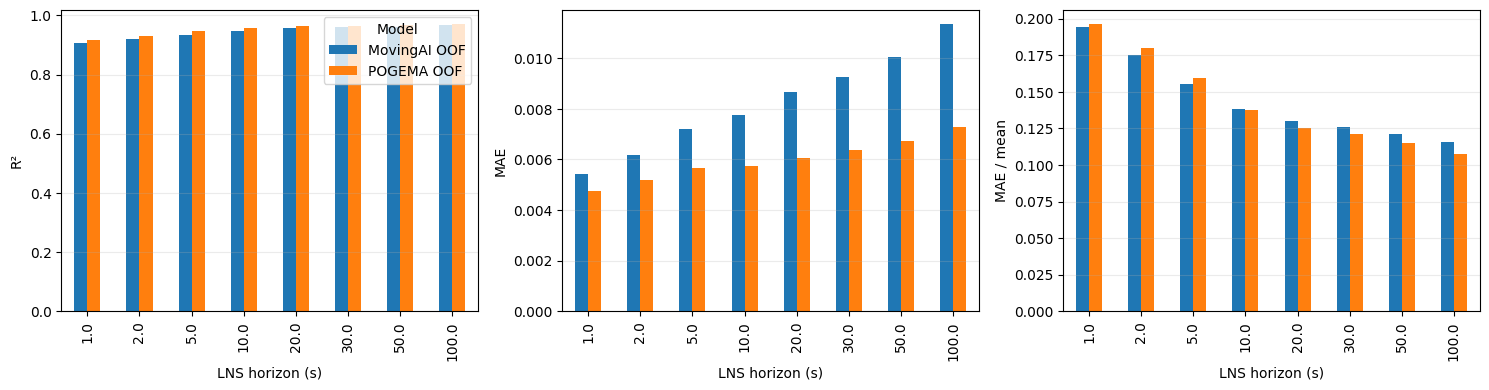

In [4]:
m1_splits = list(random_group_splits(movingai))
m2_splits = list(random_group_splits(pogema))
m1_oof, m1_models = evaluate(movingai, m1_splits)
m2_oof, m2_models = evaluate(pogema, m2_splits)
m1_baseline, m2_baseline = baseline(movingai, m1_splits), baseline(pogema, m2_splits)

in_domain_metrics = pd.concat({
    "MovingAI OOF": metric_table(movingai, m1_oof, m1_splits, m1_baseline),
    "POGEMA OOF": metric_table(pogema, m2_oof, m2_splits, m2_baseline),
}, names=["model"])
display(in_domain_metrics.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
table = in_domain_metrics.reset_index()
for axis, metric_name in zip(axes, ["R²", "MAE", "MAE / mean"]):
    table.pivot(index="seconds", columns="model", values=metric_name).plot.bar(ax=axis)
    axis.set(xlabel="LNS horizon (s)", ylabel=metric_name)
    axis.grid(axis="y", alpha=0.25)
    axis.legend_.remove()
axes[0].legend(title="Model")
plt.tight_layout()
plt.show()

### OOF residuals at 100 seconds

Residuals are actual minus predicted SOD/LB improvement at 100 seconds. Extreme points outside the shared plotting range are hidden from the figure only.

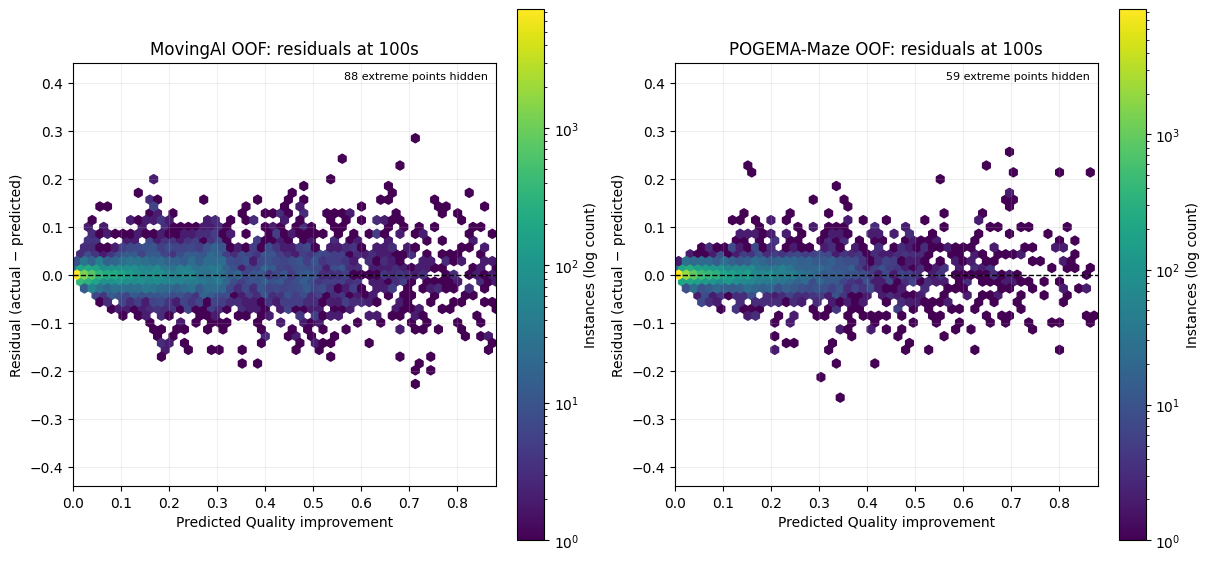

In [5]:
column_100s = TIMESTEPS.index(100.0)
DISPLAY_QUANTILE = 0.995

def plot_residual_panels(panels):
    residual_panels = [
        (name, predicted, actual - predicted)
        for name, actual, predicted in panels
    ]
    span = max(
        1e-9,
        *(float(np.quantile(predicted, DISPLAY_QUANTILE))
          for _, predicted, _ in residual_panels),
        *(2 * float(np.quantile(np.abs(residual), DISPLAY_QUANTILE))
          for _, _, residual in residual_panels),
    )
    fig, axes = plt.subplots(1, len(panels), figsize=(12, 5.5), layout="constrained")
    axes = np.atleast_1d(axes)
    for axis, (name, predicted, residual) in zip(axes, residual_panels):
        visible = (predicted <= span) & (np.abs(residual) <= span / 2)
        points = axis.hexbin(
            predicted[visible], residual[visible],
            gridsize=55, extent=(0, span, -span / 2, span / 2),
            mincnt=1, bins="log", cmap="viridis",
        )
        axis.axhline(0, color="black", linestyle="--", linewidth=1)
        axis.set_xlim(0, span)
        axis.set_ylim(-span / 2, span / 2)
        axis.set_box_aspect(1)
        axis.set(
            title=f"{name}: residuals at 100s",
            xlabel="Predicted Quality improvement",
            ylabel="Residual (actual − predicted)",
        )
        axis.grid(alpha=0.2)
        axis.text(
            0.98, 0.98, f"{(~visible).sum():,} extreme points hidden",
            transform=axis.transAxes, ha="right", va="top", fontsize=8,
        )
        fig.colorbar(points, ax=axis, label="Instances (log count)")
    plt.show()

plot_residual_panels([
    ("MovingAI OOF", movingai[TARGETS[column_100s]].to_numpy(), m1_oof[:, column_100s]),
    ("POGEMA-Maze OOF", pogema[TARGETS[column_100s]].to_numpy(), m2_oof[:, column_100s]),
])

## Performance at increasing improvement percentiles

At 100 seconds, remove the lowest-improvement instances in each held-out fold and recompute model and baseline metrics.

In [6]:
def percentile_metrics(data, splits, prediction, mean_prediction, label):
    column, target = len(TIMESTEPS) - 1, TARGETS[-1]
    actual = data[target].to_numpy()
    rows = []
    for fold, (_, test) in enumerate(splits, start=1):
        fold_actual = actual[test]
        for percentile in range(10, 90, 10):
            keep = fold_actual >= np.percentile(fold_actual, percentile)
            rows.append({
                "dataset": label, "fold": fold,
                "bottom removed (%)": percentile,
                "instances": int(keep.sum()),
                **metrics(fold_actual[keep], prediction[test, column][keep]),
                **{
                    f"Baseline {name}": value
                    for name, value in metrics(
                        fold_actual[keep], mean_prediction[test, column][keep]
                    ).items()
                },
            })
    return pd.DataFrame(rows)

percentile_fold_metrics = pd.concat([
    percentile_metrics(movingai, m1_splits, m1_oof, m1_baseline, "MovingAI"),
    percentile_metrics(pogema, m2_splits, m2_oof, m2_baseline, "POGEMA"),
], ignore_index=True)
percentile_results = (
    percentile_fold_metrics.groupby(["dataset", "bottom removed (%)"], as_index=False)
    .agg({
        "instances": "sum", "R²": "mean", "MAE": "mean",
        "MAE / mean": "mean", "Baseline R²": "mean",
        "Baseline MAE": "mean", "Baseline MAE / mean": "mean",
    })
)
display(percentile_results.set_index(["dataset", "bottom removed (%)"]).round(4))

instances      R²     MAE  MAE / mean  \
dataset  bottom removed (%)                                          
MovingAI 10                      15738  0.9649  0.0126      0.1157   
         20                      13989  0.9631  0.0141      0.1151   
         30                      12241  0.9606  0.0158      0.1132   
         40                      10493  0.9571  0.0178      0.1106   
         50                       8747  0.9519  0.0204      0.1070   
         60                       6996  0.9439  0.0237      0.1030   
         70                       5248  0.9309  0.0277      0.0973   
         80                       3500  0.9075  0.0337      0.0927   
POGEMA   10                      16542  0.9688  0.0080      0.1061   
         20                      14702  0.9675  0.0088      0.1048   
         30                      12864  0.9660  0.0099      0.1032   
         40                      11026  0.9638  0.0112      0.1016   
         50                       9192  0.9608  0.0128      0.0992   
         60                       7351  0.9562  0.0150      0.0965   
         70                       5515  0.9491  0.0178      0.0918   
         80                       3676  0.9371  0.0221      0.0876   

                             Baseline R²  Baseline MAE  Baseline MAE / mean  
dataset  bottom removed (%)                                                  
MovingAI 10                       0.0379        0.1006               0.9276  
         20                       0.0251        0.1010               0.8280  
         30                      -0.0108        0.1039               0.7468  
         40                      -0.0874        0.1126               0.6983  
         50                      -0.2176        0.1260               0.6620  
         60                      -0.4501        0.1473               0.6409  
         70                      -0.8979        0.1875               0.6584  
         80                      -1.8139        0.2656               0.7309  
POGEMA   10                       0.0615        0.0607               0.8069  
         20                       0.0359        0.0645               0.7639  
         30                      -0.0049        0.0702               0.7326  
         40                      -0.0650        0.0777               0.7039  
         50                      -0.1533        0.0871               0.6721  
         60                      -0.2956        0.1013               0.6496  
         70                      -0.5436        0.1272               0.6570  
         80                      -1.0235        0.1844               0.7306

## Feature ablation

R²     MAE  MAE / mean
features             seconds                            
s1 features          1.0      0.9088  0.0058      0.2092
                     2.0      0.9231  0.0066      0.1858
                     5.0      0.9350  0.0077      0.1667
                     10.0     0.9449  0.0086      0.1526
                     20.0     0.9509  0.0098      0.1478
                     30.0     0.9536  0.0107      0.1461
                     50.0     0.9550  0.0121      0.1460
                     100.0    0.9554  0.0143      0.1467
static + s1 features 1.0      0.9082  0.0054      0.1943
                     2.0      0.9207  0.0062      0.1755
                     5.0      0.9346  0.0072      0.1554
                     10.0     0.9485  0.0077      0.1380
                     20.0     0.9562  0.0087      0.1301
                     30.0     0.9592  0.0093      0.1260
                     50.0     0.9623  0.0101      0.1214
                     100.0    0.9662  0.0113      0.1161
static features      1.0      0.6834  0.0094      0.3367
                     2.0      0.7394  0.0106      0.3002
                     5.0      0.7952  0.0125      0.2681
                     10.0     0.8312  0.0139      0.2474
                     20.0     0.8559  0.0156      0.2333
                     30.0     0.8662  0.0166      0.2268
                     50.0     0.8774  0.0182      0.2194
                     100.0    0.8887  0.0206      0.2107

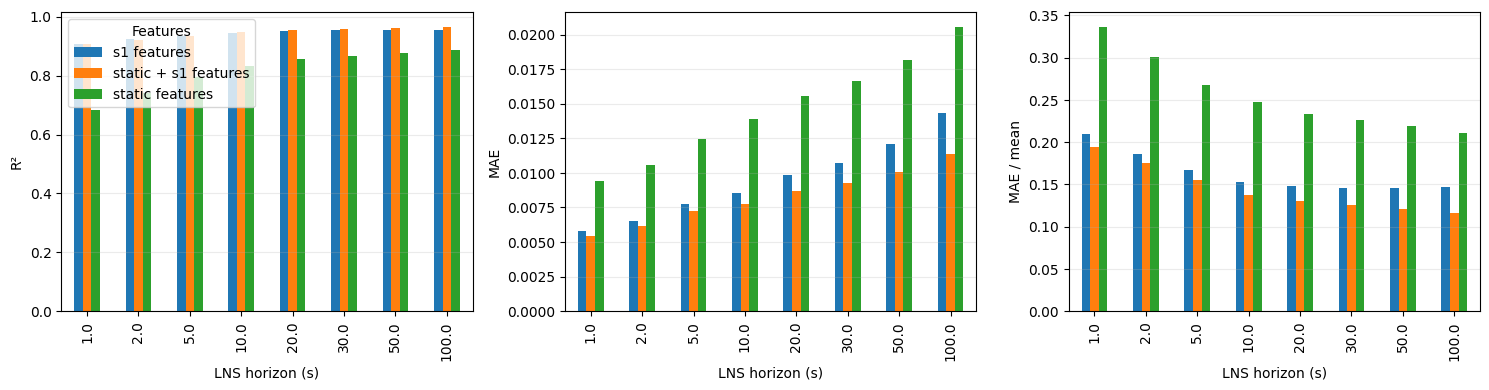

R²     MAE  MAE / mean
features             seconds                            
s1 features          1.0      0.9145  0.0051      0.2099
                     2.0      0.9298  0.0054      0.1870
                     5.0      0.9427  0.0059      0.1657
                     10.0     0.9516  0.0061      0.1461
                     20.0     0.9565  0.0065      0.1354
                     30.0     0.9594  0.0068      0.1292
                     50.0     0.9616  0.0072      0.1228
                     100.0    0.9636  0.0078      0.1153
static + s1 features 1.0      0.9175  0.0048      0.1962
                     2.0      0.9311  0.0052      0.1802
                     5.0      0.9458  0.0056      0.1595
                     10.0     0.9571  0.0057      0.1380
                     20.0     0.9630  0.0060      0.1254
                     30.0     0.9651  0.0064      0.1209
                     50.0     0.9676  0.0067      0.1151
                     100.0    0.9696  0.0073      0.1076
static features      1.0      0.7661  0.0085      0.3544
                     2.0      0.7922  0.0094      0.3279
                     5.0      0.8192  0.0106      0.2999
                     10.0     0.8362  0.0115      0.2779
                     20.0     0.8481  0.0127      0.2646
                     30.0     0.8554  0.0134      0.2554
                     50.0     0.8616  0.0144      0.2464
                     100.0    0.8701  0.0155      0.2290

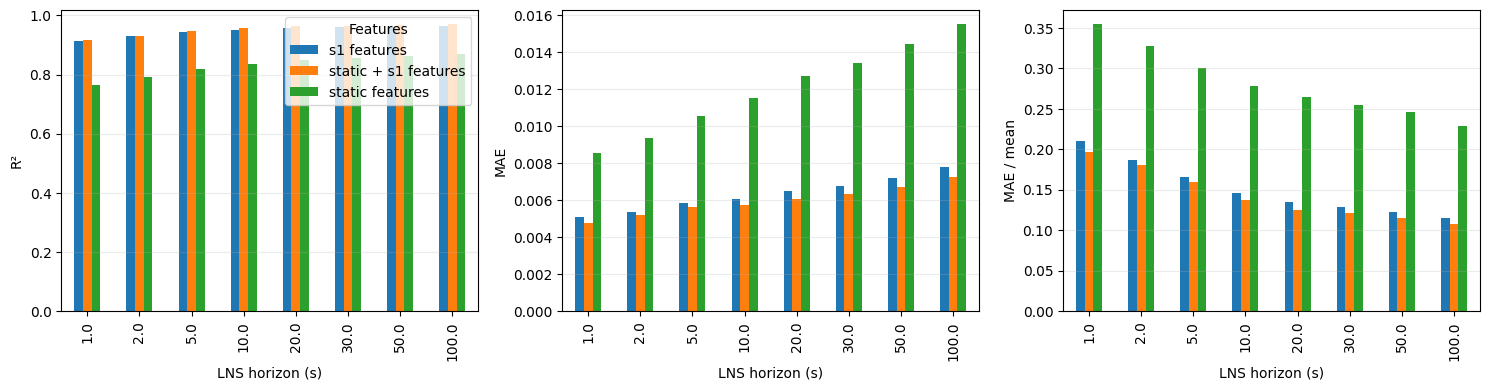

In [7]:
def ablation(data, splits, full_prediction, label):
    variants = {
        "static + s1 features": full_prediction,
        "static features": evaluate(data, splits, tuple(STATIC_FEATURES))[0],
        "s1 features": evaluate(data, splits, tuple(LACAM_FEATURES))[0],
    }
    rows = []
    for name, prediction in variants.items():
        for fold, (_, test) in enumerate(splits, start=1):
            for column, (second, target) in enumerate(zip(TIMESTEPS, TARGETS)):
                rows.append({
                    "features": name, "fold": fold, "seconds": second,
                    **metrics(data.iloc[test][target], prediction[test, column]),
                })
    result = (
        pd.DataFrame(rows).groupby(["features", "seconds"], as_index=False)
        [["R²", "MAE", "MAE / mean"]].mean()
    )
    display(result.set_index(["features", "seconds"]).round(4))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for axis, metric_name in zip(axes, ["R²", "MAE", "MAE / mean"]):
        result.pivot(index="seconds", columns="features", values=metric_name).plot.bar(ax=axis)
        axis.set(xlabel="LNS horizon (s)", ylabel=metric_name)
        axis.grid(axis="y", alpha=0.25)
        axis.legend_.remove()
    axes[0].legend(title="Features")
    plt.tight_layout()
    plt.show()
    return result

m1_ablation = ablation(movingai, m1_splits, m1_oof, "MovingAI")
m2_ablation = ablation(pogema, m2_splits, m2_oof, "POGEMA")

## Five-fold cross-domain evaluation

Each source-fold model is evaluated on the other dataset at all eight horizons. The table reports means and standard deviations across folds; the residual plots use source fold 2.

MAE / mean        
                                mean     std
transfer          seconds                   
MovingAI → POGEMA 1.0         0.3042  0.0118
                  2.0         0.2981  0.0068
                  5.0         0.2757  0.0019
                  10.0        0.2553  0.0034
                  20.0        0.2551  0.0043
                  30.0        0.2433  0.0026
                  50.0        0.2444  0.0042
                  100.0       0.2548  0.0081
POGEMA → MovingAI 1.0         0.4258  0.0355
                  2.0         0.4203  0.0235
                  5.0         0.4114  0.0230
                  10.0        0.3794  0.0254
                  20.0        0.3367  0.0206
                  30.0        0.3242  0.0219
                  50.0        0.3128  0.0280
                  100.0       0.3064  0.0293

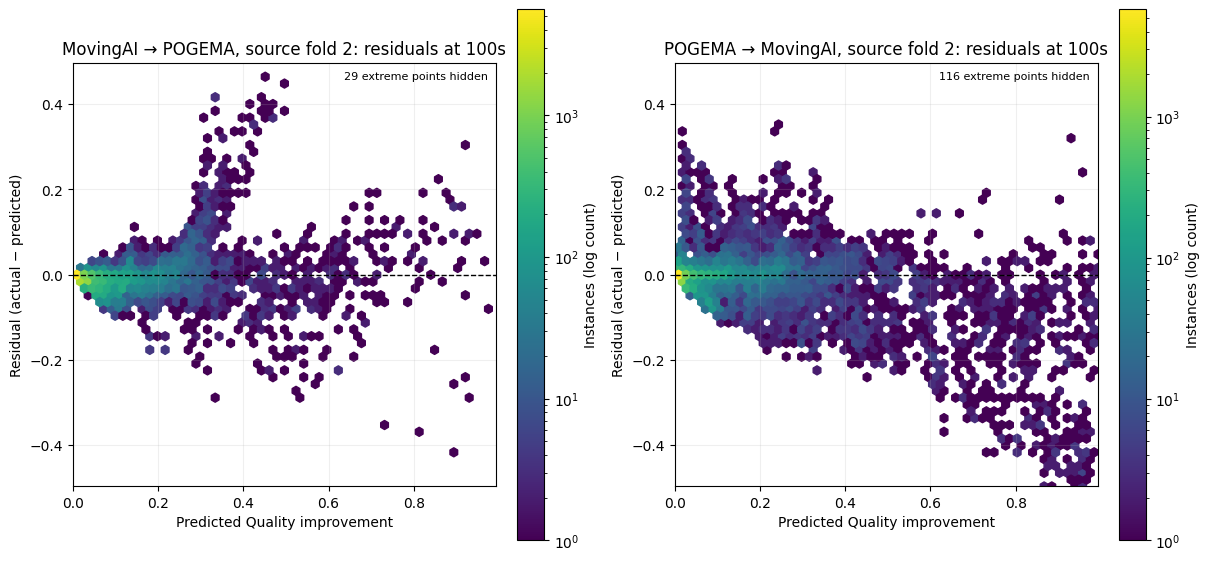

In [8]:
CROSS_RESIDUAL_FOLD = 2

def cross_domain(source, target, splits):
    rows = []
    residual_prediction = None
    for fold, (train, _) in enumerate(splits, start=1):
        estimator = fit_model(source.iloc[train], SEED + fold)
        prediction = predict_model(estimator, target)
        if fold == CROSS_RESIDUAL_FOLD:
            residual_prediction = prediction
        for column, (second, target_name) in enumerate(zip(TIMESTEPS, TARGETS)):
            rows.append({
                "fold": fold, "seconds": second,
                **metrics(target[target_name], prediction[:, column]),
            })
    if residual_prediction is None:
        raise ValueError(f"Missing source fold {CROSS_RESIDUAL_FOLD}")
    return pd.DataFrame(rows), residual_prediction

m1_on_pogema, m1_on_pogema_residual_prediction = cross_domain(
    movingai, pogema, m1_splits
)
m2_on_movingai, m2_on_movingai_residual_prediction = cross_domain(
    pogema, movingai, m2_splits
)
cross_rows = pd.concat({
    "MovingAI → POGEMA": m1_on_pogema,
    "POGEMA → MovingAI": m2_on_movingai,
}, names=["transfer", "row"]).reset_index(level="row", drop=True).reset_index()
cross_metrics = cross_rows.groupby(["transfer", "seconds"])[
    ["MAE / mean"]
].agg(["mean", "std"])
display(cross_metrics.round(4))

plot_residual_panels([
    (
        f"MovingAI → POGEMA, source fold {CROSS_RESIDUAL_FOLD}",
        pogema[TARGETS[column_100s]].to_numpy(),
        m1_on_pogema_residual_prediction[:, column_100s],
    ),
    (
        f"POGEMA → MovingAI, source fold {CROSS_RESIDUAL_FOLD}",
        movingai[TARGETS[column_100s]].to_numpy(),
        m2_on_movingai_residual_prediction[:, column_100s],
    ),
])

MAE / mean        
                                mean     std
evaluation        seconds                   
MovingAI → POGEMA 1.0         0.3042  0.0118
                  2.0         0.2981  0.0068
                  5.0         0.2757  0.0019
                  10.0        0.2553  0.0034
                  20.0        0.2551  0.0043
                  30.0        0.2433  0.0026
                  50.0        0.2444  0.0042
                  100.0       0.2548  0.0081
POGEMA → POGEMA   1.0         0.1962  0.0123
                  2.0         0.1802  0.0084
                  5.0         0.1595  0.0091
                  10.0        0.1380  0.0068
                  20.0        0.1254  0.0033
                  30.0        0.1209  0.0028
                  50.0        0.1151  0.0039
                  100.0       0.1076  0.0051

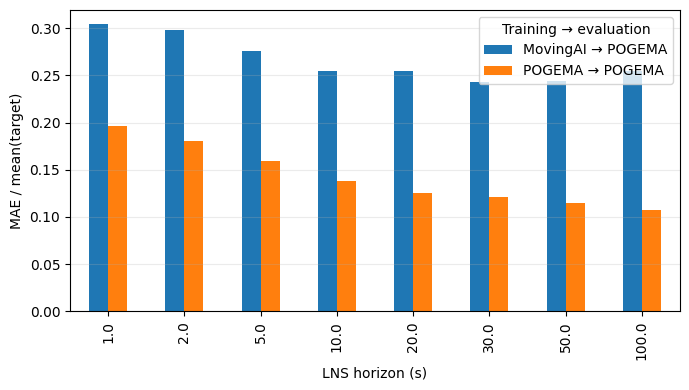

MAE / mean        
                                  mean     std
evaluation          seconds                   
MovingAI → MovingAI 1.0         0.1943  0.0165
                    2.0         0.1755  0.0145
                    5.0         0.1554  0.0099
                    10.0        0.1380  0.0085
                    20.0        0.1301  0.0106
                    30.0        0.1260  0.0102
                    50.0        0.1214  0.0089
                    100.0       0.1161  0.0054
POGEMA → MovingAI   1.0         0.4258  0.0355
                    2.0         0.4203  0.0235
                    5.0         0.4114  0.0230
                    10.0        0.3794  0.0254
                    20.0        0.3367  0.0206
                    30.0        0.3242  0.0219
                    50.0        0.3128  0.0280
                    100.0       0.3064  0.0293

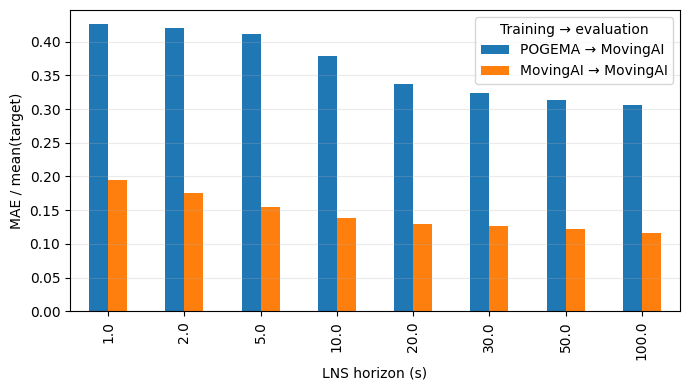

In [9]:
def in_domain_fold_metrics(data, splits, predictions):
    rows = []
    for fold, (_, test) in enumerate(splits, start=1):
        for column, (second, target_name) in enumerate(zip(TIMESTEPS, TARGETS)):
            rows.append({
                "fold": fold,
                "seconds": second,
                **metrics(data.iloc[test][target_name], predictions[test, column]),
            })
    return pd.DataFrame(rows)

m1_on_movingai = in_domain_fold_metrics(movingai, m1_splits, m1_oof)
m2_on_pogema = in_domain_fold_metrics(pogema, m2_splits, m2_oof)

def plot_transfer_vs_in_domain(transfer, in_domain, labels):
    fold_metrics = pd.concat(
        {labels[0]: transfer, labels[1]: in_domain},
        names=["evaluation", "row"],
    ).reset_index(level="row", drop=True).reset_index()
    summary = fold_metrics.groupby(["evaluation", "seconds"])[
        ["MAE / mean"]
    ].agg(["mean", "std"])
    display(summary.round(4))

    metric_mean = summary[("MAE / mean", "mean")].unstack("evaluation")[list(labels)]
    axis = metric_mean.plot.bar(figsize=(7, 4))
    axis.set(xlabel="LNS horizon (s)", ylabel="MAE / mean(target)")
    axis.grid(axis="y", alpha=0.25)
    axis.legend(title="Training → evaluation")
    plt.tight_layout()
    plt.show()

plot_transfer_vs_in_domain(
    m1_on_pogema, m2_on_pogema,
    ("MovingAI → POGEMA", "POGEMA → POGEMA"),
)
plot_transfer_vs_in_domain(
    m2_on_movingai, m1_on_movingai,
    ("POGEMA → MovingAI", "MovingAI → MovingAI"),
)